# SPHEREx spectrophotometry of Nova Centauri 2025

An end-to-end check of `obsutils.spherex` on a transient that SPHEREx cannot have missed.

**V1935 Cen** erupted on 2025-09-22 at V = 6.2, just below naked-eye visibility. A classical
nova is close to an ideal test case: there is no host galaxy, the progenitor system is
invisible beforehand at these wavelengths, and the amplitude is enormous. If the pipeline
cannot recover this, nothing else it says is worth much.

It also exercises the harder parts. The nova sits at galactic latitude +1.3 degrees, so the
field is crowded and the deblending has real work to do, and it fades over the eight months
SPHEREx watched it, which is what the per-block stacking is for.

The companion notebook [spherex_photometry.ipynb](spherex_photometry.ipynb) walks through the
same machinery step by step on a TDE. This one runs it in a single call and then asks whether
the answers are right.

In [1]:
import logging

import numpy as np
import pandas as pd
from astropy.time import Time

from obsutils.spherex import (
    archival_photometry,
    plot_lightcurve,
    plot_sed,
    run_photometry,
    save_plots,
)
from obsutils.spherex.pipeline import block_summary

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

## Run it

Sesame resolves the name, so no coordinates are needed. `deblend=True` fits the catalogued
neighbours alongside the nova and tilts the fitted background, which matters in a plane field.

In [2]:
source = "V1935 Cen"
eruption_mjd = Time("2025-09-22").mjd

result = run_photometry(source, reference_mjd=eruption_mjd, deblend=True)

print(f"{result.name}: {result.coord.to_string('hmsdms')}, galactic b = {result.coord.galactic.b:.1f}")
print(f"eruption MJD {eruption_mjd:.0f}; {len(result.images)} images, {len(result.photometry)} measured")
print(f"blocks: {list(result.stacks)}")

INFO obsutils.spherex.query: Resolved V1935 Cen to 14h37m21.7699992s -58d47m39.999984s


INFO obsutils.spherex.query: Found 416 SPHEREx images, MJD 60876.3 to 61258.9


INFO obsutils.spherex.psf: Loaded ePSF for detector 4 (epsf_D4_spx_cal-epsf-v1-2026-191.fits, 441 zones)


INFO obsutils.spherex.query: Fitting 5 companions within 40 arcsec, at 10.1, 12.1, 24.5, 34.5, 34.3 arcsec


INFO obsutils.spherex.calibration: Loaded solid angle pixel maps for qr2 (cal-sapm-v2-2025-164)


...

INFO obsutils.spherex.stack: Stacked 3 blocks: pre (n = 117), post 1 (n = 133), post 2 (n = 131)


INFO obsutils.spherex.stack: post 1: rms(sigma) = 13.21 over 28 bins


INFO obsutils.spherex.stack: post 2: rms(sigma) = 7.80 over 28 bins


INFO obsutils.spherex.pipeline: Wrote SPHEREx products to /Users/rdstein/Data/obsutils/V1935_Cen/spherex


V1935 Cen: 14h37m21.7699992s -58d47m39.999984s, galactic b = 1.3 deg
eruption MJD 60940; 416 images, 416 measured
blocks: ['pre', 'post 1', 'post 2']


## Did it find the nova?

One line per survey pass, giving its mean offset from the pre-eruption baseline averaged over
wavelength.

In [3]:
block_summary(result.difference)

,block,phase_days,bins,offset_uJy,offset_err,sigma,rms_sigma
0,post 1,144.0,28,3956.9,60.8,65.1,13.21
1,post 2,308.0,28,2056.1,56.9,36.1,7.80


That is the headline result: a **65 sigma** detection in the first pass after the eruption, and
the nova has faded to roughly half that by the second, some five months later. Averaging the
two passes together, which is what stacking all post-reference epochs would do, would report
their mean and hide the decline entirely.

The detection is not carried by one or two bins either.

In [4]:
for block, group in result.difference.groupby("block", sort=False):
    detected = (group["diff"] / group["diff_err"] > 3).sum()
    print(f"{block}: {detected}/{len(group)} wavelength bins above 3 sigma, "
          f"difference positive in {(group['diff'] > 0).sum()}/{len(group)}")

post 1: 28/28 wavelength bins above 3 sigma, difference positive in 28/28
post 2: 24/28 wavelength bins above 3 sigma, difference positive in 28/28


## The spectra

This is the plot the whole pipeline exists to produce. The pre-eruption baseline is the grey
dashed curve; each survey pass after the eruption is its own colour, labelled by how long after
the eruption it was taken. The lower panel is each pass minus the baseline.

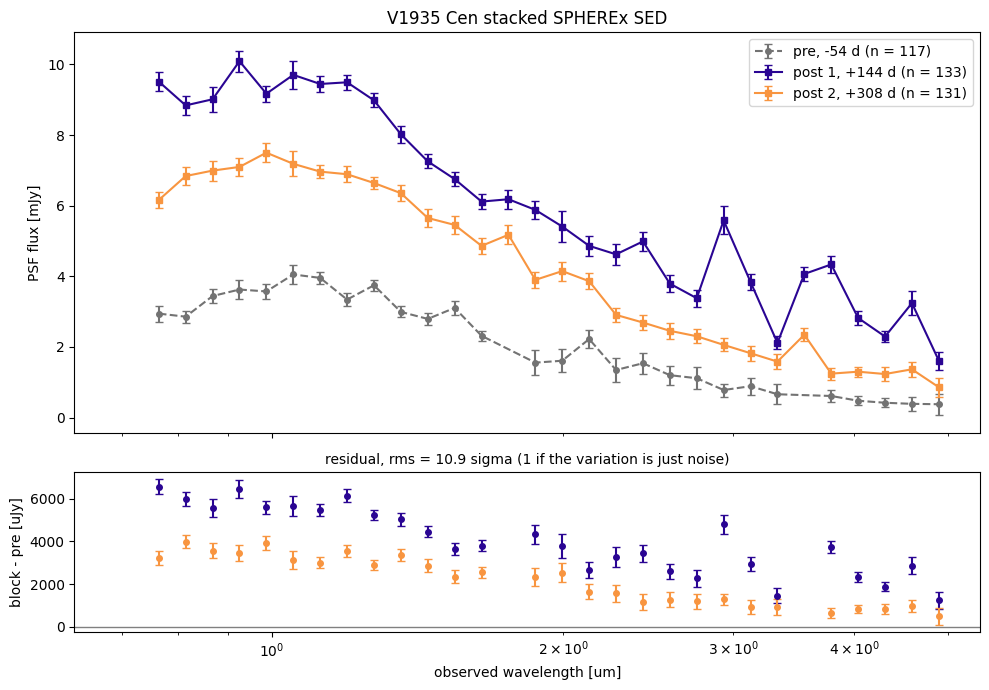

In [5]:
plot_sed(result.stacks, title=source, difference=result.difference);

The eruption and the fade are both plainly visible, and the fade is not grey: the source drops
by about a third at 0.8 microns and by about half at 3 microns over those five months, so its
spectral shape is evolving too. Stacking the two passes together would have averaged all of
that into a single curve.

## The light curve

Each point is one exposure, coloured by the wavelength that exposure happened to sample. The
bursts are the survey passes: the position is revisited about every six months, in a window
spanning a few weeks. Scatter within a burst is mostly the wavelength changing between
exposures, not the nova varying.

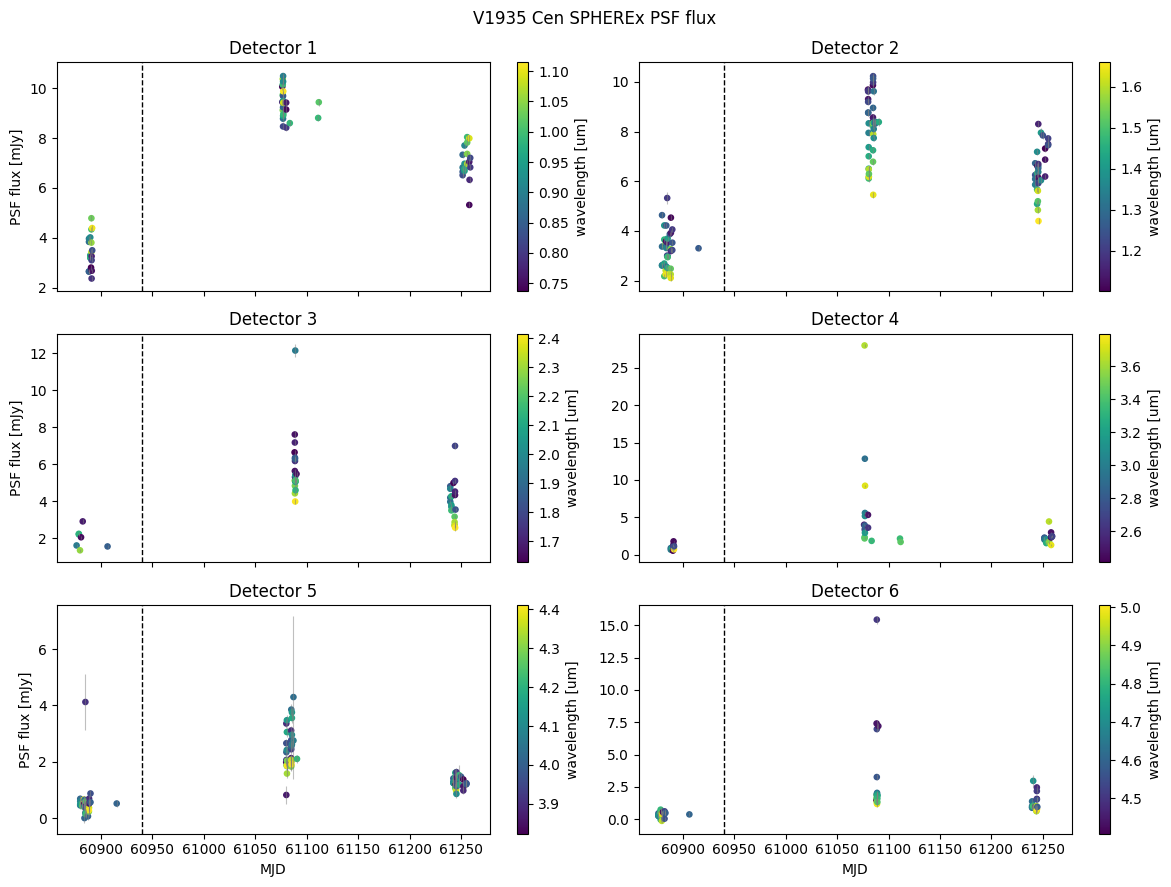

In [6]:
plot_lightcurve(result.photometry, reference_mjd=eruption_mjd, title=source);

## What was there before the eruption?

This is the other half of the test. A quiescent nova progenitor contributes almost nothing at
these wavelengths, so whatever the pre-eruption stack measures ought to be explained by other
sources sharing the PSF, and the catalogues say what those are.

In [7]:
pre = result.stacks["pre"]
blue = pre[pre["wavelength"] < 1.5]
red = pre[pre["wavelength"] > 3.5]

for label, subset in [("blue, < 1.5 um", blue), ("red, > 3.5 um", red)]:
    weights = 1.0 / subset["flux_err"] ** 2
    mean = np.sum(subset["flux"] * weights) / np.sum(weights)
    err = 1.0 / np.sqrt(np.sum(weights))
    print(f"pre-eruption {label:>14}: {mean / 1e3:+6.2f} +- {err / 1e3:.2f} mJy")

pre-eruption blue, < 1.5 um:  +3.34 +- 0.06 mJy
pre-eruption  red, > 3.5 um:  +0.47 +- 0.07 mJy


So the baseline is not zero: about 3.3 mJy in the near-infrared and 0.5 mJy in the
mid-infrared, both measured at high significance. That is not a failure. Something really is
there, and the catalogues say what.

In [8]:
# What the catalogues say sits at this position, weighted by how much of each
# source's light a PSF centred on the nova would collect. The pipeline does not
# do this by default; pass archival=True, or --archival, to have it overlaid on
# the SED as well.
archival_photometry(result.coord)[["band", "wavelength", "flux", "n_sources", "nearest_arcsec"]]

INFO obsutils.spherex.archival: 3 WISE source(s) using elliptical aperture magnitudes


INFO obsutils.spherex.archival: Archival estimate in 5 bands, 0.47 to 5.70 mJy


,band,wavelength,flux,n_sources,nearest_arcsec
0,2MASS J,1.235,5703.051712,19,1.725893
1,2MASS H,1.662,4820.316415,19,1.725893
2,2MASS Ks,2.159,3539.385048,19,1.725893
3,WISE W1,3.353,1635.062141,4,1.671759
4,WISE W2,4.603,474.227864,4,1.671759


A star sits **1.7 arcsec** from the nova position, about a quarter of a SPHEREx pixel, so it is
completely unresolvable from it. 2MASS gives it J = 13.79, and a PSF fit centred on the nova
collects around three quarters of its light. That, plus the rest of a crowded plane field, is
what the baseline is measuring, and the archival estimate above brackets it: the measured
baseline runs below the estimate, by a factor of about two in the near-infrared and more in the
mid-infrared, which is the direction and the size of the disagreement expected in a field this
crowded, where the fitted sky term absorbs stellar confusion that a catalogue sum counts as
source flux.

The shape is the giveaway that it is stellar: the baseline falls off like a Rayleigh-Jeans
tail, from 3.3 mJy in the near-infrared to 0.5 mJy by 4 microns, whereas the nova's own
spectrum is far redder.

Whether that star is the progenitor system or an unrelated field star is not something SPHEREx
can settle. In a field with 25 2MASS sources per square arcminute there is a few percent chance
of an unrelated star landing that close. It does not matter for the measurement: the star is
constant, so it cancels in the difference.

That is the general lesson, and it applies to the TDE notebook too. The absolute flux at a
position is whatever happens to share the PSF with the target; only the change between epochs
belongs to the transient.

## A trap worth knowing about

The stacks rescale the formal errors by a factor measured from the data, because the propagated
errors understate how much the photometry repeats to. **Where that factor is measured from
matters enormously for a variable source.**

`stack_by_block` measures it on the pre-reference epochs, where the transient is absent. Measure
it over every epoch instead and the nova's own fading is counted as noise:

In [9]:
from obsutils.spherex import error_inflation_factor, default_wavelength_edges

edges = default_wavelength_edges(30)
measured = result.photometry[np.isfinite(result.photometry["flux"])]

all_epochs = error_inflation_factor(measured, edges=edges)
pre_only = error_inflation_factor(measured[measured["phase"] == "pre"], edges=edges, min_per_bin=3)

print(f"inflation factor from all epochs:          {all_epochs:5.1f}")
print(f"inflation factor from pre-eruption epochs: {pre_only:5.1f}")

INFO obsutils.spherex.stack: Formal errors understate the epoch scatter by a factor 17.87, from 28 bins


WARNING obsutils.spherex.stack: An inflation factor of 17.9 is large. If the source varies within the epochs used, its variability is being counted as noise; calibrate on epochs where the transient is absent instead.


INFO obsutils.spherex.stack: Formal errors understate the epoch scatter by a factor 3.93, from 17 bins


inflation factor from all epochs:           17.9
inflation factor from pre-eruption epochs:   3.9


Calibrating on all epochs would inflate the errors more than four times too far, and that alone
would take this from a 65 sigma detection to under 5 sigma. The same comparison on
a non-variable source changes the factor by a few percent, so the gap is a signature of real
variability rather than of noise.

In [10]:
# Write the tables and the four plots to $OUTPUT_DIR/<name>/spherex.
save_plots(result)
print(result.output_dir)

INFO obsutils.spherex.pipeline: Wrote SPHEREx plots to /Users/rdstein/Data/obsutils/V1935_Cen/spherex


/Users/rdstein/Data/obsutils/V1935_Cen/spherex


## Summary

| check | result |
|---|---|
| eruption detected | +3.96 mJy at +144 d, 65 sigma |
| fade resolved | +2.06 mJy at +308 d, in a separate survey pass |
| bins above 3 sigma | 28 of 28 in the first pass, 24 of 28 in the second |
| difference positive | in every bin, in both passes |
| pre-eruption baseline | stellar in shape, and explained by a star 1.7 arcsec away |

Against published IRSA forced-PSF spectrophotometry of three other Galactic transients, the
fluxes here agree to a median ratio of 1.05 and the errors to 3 percent. See
[README_spherex_validation.md](README_spherex_validation.md) for that comparison and for the
cases where the pipeline does less well, in particular how much the archival overlay
over-predicts in a crowded field like this one.